In [52]:
# ============================================================
# BLOCK 1 — Install & Import Libraries
# ============================================================
!pip install -q seaborn matplotlib pandas numpy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
pd.set_option('display.max_columns', 50)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [53]:
# ============================================================
# BLOCK 2 — Load Dataset
# ============================================================

train = pd.read_csv('fraudTrain.csv')
test  = pd.read_csv('fraudTest.csv')

print("=" * 60)
print("DATASETS LOADED SUCCESSFULLY")
print("=" * 60)
print(f"  Train set  →  Rows: {len(train):,}  |  Cols: {train.shape[1]}")
print(f"  Test  set  →  Rows: {len(test):,}   |  Cols: {test.shape[1]}")
print(f"\n  Columns ({len(train.columns)}):")
for i, col in enumerate(train.columns, 1):
    print(f"    {i:2}. {col}")
print("=" * 60)

DATASETS LOADED SUCCESSFULLY
  Train set  →  Rows: 1,296,675  |  Cols: 23
  Test  set  →  Rows: 555,719   |  Cols: 23

  Columns (23):
     1. Unnamed: 0
     2. trans_date_trans_time
     3. cc_num
     4. merchant
     5. category
     6. amt
     7. first
     8. last
     9. gender
    10. street
    11. city
    12. state
    13. zip
    14. lat
    15. long
    16. city_pop
    17. job
    18. dob
    19. trans_num
    20. unix_time
    21. merch_lat
    22. merch_long
    23. is_fraud


In [54]:
# ============================================================
# BLOCK 3 — Basic Overview
# ============================================================

print("=" * 60)
print("TRAIN DATASET — BASIC OVERVIEW")
print("=" * 60)
print(f"\n📌 Shape     : {train.shape}")
print(f"\n📌 Data Types:\n{train.dtypes}")
print(f"\n📌 First 5 rows:")
train.head()

TRAIN DATASET — BASIC OVERVIEW

📌 Shape     : (1296675, 23)

📌 Data Types:
Unnamed: 0                 int64
trans_date_trans_time     object
cc_num                     int64
merchant                  object
category                  object
amt                      float64
first                     object
last                      object
gender                    object
street                    object
city                      object
state                     object
zip                        int64
lat                      float64
long                     float64
city_pop                   int64
job                       object
dob                       object
trans_num                 object
unix_time                  int64
merch_lat                float64
merch_long               float64
is_fraud                   int64
dtype: object

📌 First 5 rows:


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,24433,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [55]:
# ============================================================
# BLOCK 4 — Statistical Summary
# ============================================================

print("=" * 60)
print("STATISTICAL SUMMARY — NUMERIC COLUMNS")
print("=" * 60)
print(train.describe().T.to_string())

print("\n")
print("=" * 60)
print("STATISTICAL SUMMARY — CATEGORICAL COLUMNS")
print("=" * 60)
print(train.describe(include='object').T.to_string())

STATISTICAL SUMMARY — NUMERIC COLUMNS
                count          mean           std           min           25%           50%           75%           max
Unnamed: 0  1296675.0  6.483370e+05  3.743180e+05  0.000000e+00  3.241685e+05  6.483370e+05  9.725055e+05  1.296674e+06
cc_num      1296675.0  4.171920e+17  1.308806e+18  6.041621e+10  1.800429e+14  3.521417e+15  4.642255e+15  4.992346e+18
amt         1296675.0  7.035104e+01  1.603160e+02  1.000000e+00  9.650000e+00  4.752000e+01  8.314000e+01  2.894890e+04
zip         1296675.0  4.880067e+04  2.689322e+04  1.257000e+03  2.623700e+04  4.817400e+04  7.204200e+04  9.978300e+04
lat         1296675.0  3.853762e+01  5.075808e+00  2.002710e+01  3.462050e+01  3.935430e+01  4.194040e+01  6.669330e+01
long        1296675.0 -9.022634e+01  1.375908e+01 -1.656723e+02 -9.679800e+01 -8.747690e+01 -8.015800e+01 -6.795030e+01
city_pop    1296675.0  8.882444e+04  3.019564e+05  2.300000e+01  7.430000e+02  2.456000e+03  2.032800e+04  2.906700e+06
un

MISSING VALUES CHECK

  Train set — Total missing: 0
  Test  set — Total missing: 0


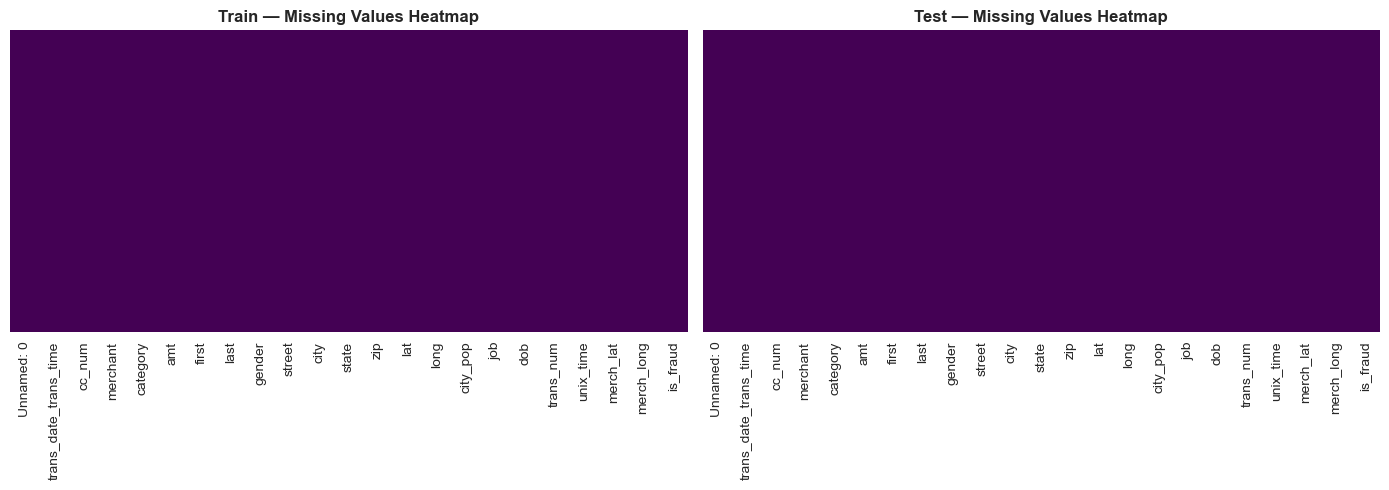


✅ No missing values in either dataset!


In [56]:
# ============================================================
# BLOCK 5 — Missing Values Check
# ============================================================

train_missing = train.isnull().sum()
test_missing  = test.isnull().sum()

print("=" * 60)
print("MISSING VALUES CHECK")
print("=" * 60)
print(f"\n  Train set — Total missing: {train_missing.sum()}")
print(f"  Test  set — Total missing: {test_missing.sum()}")

# Heatmap
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(train.isnull(),
            yticklabels=False,
            cbar=False,
            cmap='viridis',
            ax=axes[0])
axes[0].set_title('Train — Missing Values Heatmap',
                  fontweight='bold', fontsize=12)

sns.heatmap(test.isnull(),
            yticklabels=False,
            cbar=False,
            cmap='viridis',
            ax=axes[1])
axes[1].set_title('Test — Missing Values Heatmap',
                  fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

if train_missing.sum() == 0 and test_missing.sum() == 0:
    print("\n✅ No missing values in either dataset!")
else:
    print("\n⚠️  Missing values found — needs handling!")

In [57]:
# ============================================================
# BLOCK 6 — Duplicate Values Check
# ============================================================

train_dups = train.duplicated().sum()
test_dups  = test.duplicated().sum()

print("=" * 60)
print("DUPLICATE VALUES CHECK")
print("=" * 60)
print(f"  Train — Duplicates : {train_dups:,}")
print(f"  Test  — Duplicates : {test_dups:,}")

if train_dups == 0 and test_dups == 0:
    print("\n✅ No duplicate rows in either dataset!")
else:
    print("\n⚠️  Duplicates found — needs handling!")
print("=" * 60)

DUPLICATE VALUES CHECK
  Train — Duplicates : 0
  Test  — Duplicates : 0

✅ No duplicate rows in either dataset!


CLASS DISTRIBUTION
  TRAIN — Normal: 1,289,169 (99.42%)  |  Fraud: 7,506 (0.5789%)
  TEST  — Normal: 553,574  (99.61%)  |  Fraud: 2,145  (0.3860%)


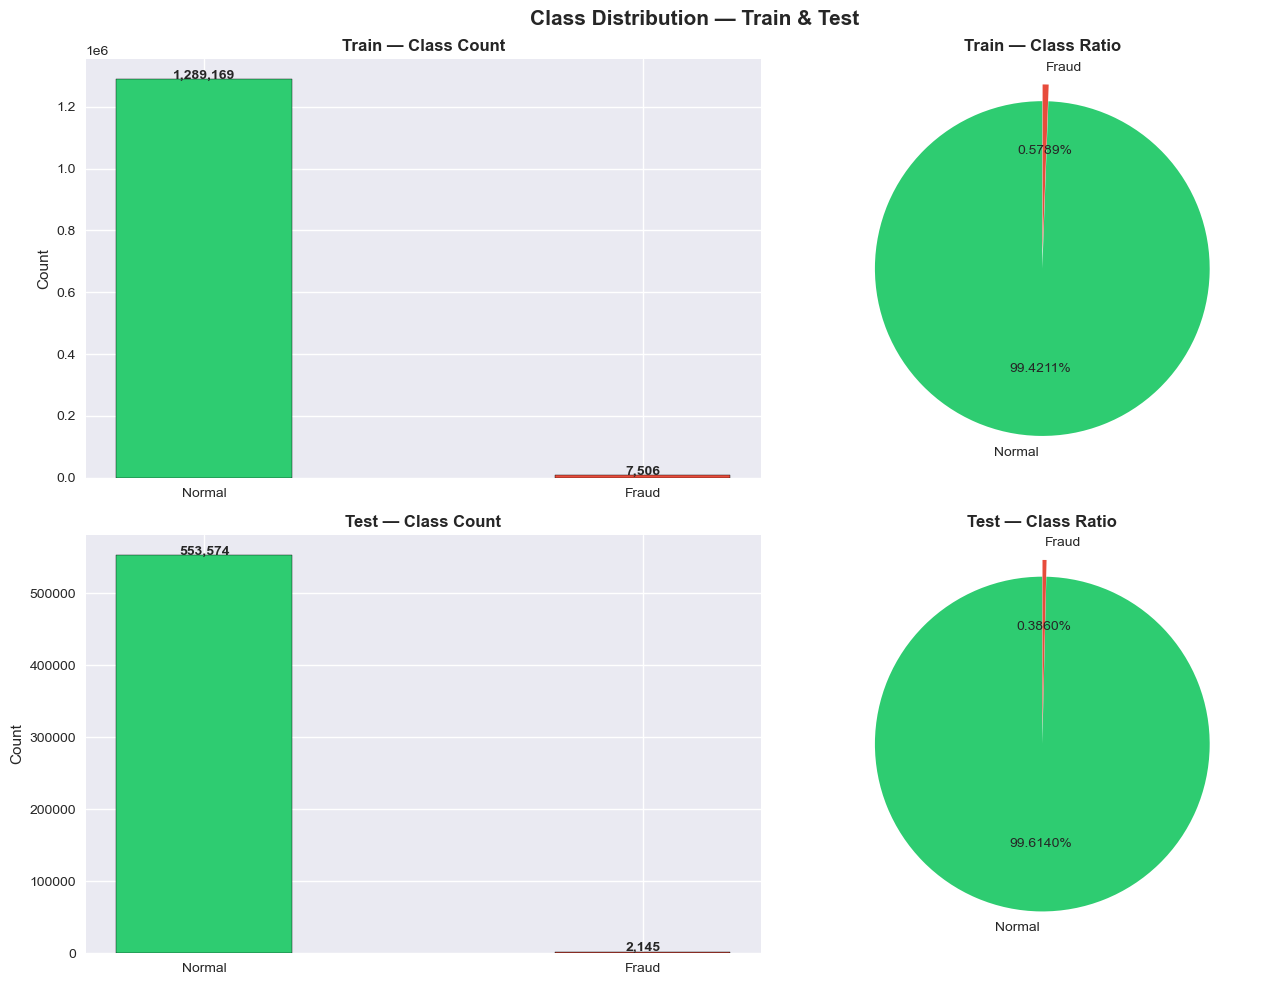


⚠️  Severe imbalance detected — SMOTE will fix this in preprocessing!


In [58]:
# ============================================================
# BLOCK 7 — Class Distribution (is_fraud)
# ============================================================

train_fraud  = train['is_fraud'].sum()
train_normal = (train['is_fraud'] == 0).sum()
test_fraud   = test['is_fraud'].sum()
test_normal  = (test['is_fraud'] == 0).sum()

print("=" * 60)
print("CLASS DISTRIBUTION")
print("=" * 60)
print(f"  TRAIN — Normal: {train_normal:,} ({train_normal/len(train)*100:.2f}%)"
      f"  |  Fraud: {train_fraud:,} ({train_fraud/len(train)*100:.4f}%)")
print(f"  TEST  — Normal: {test_normal:,}  ({test_normal/len(test)*100:.2f}%)"
      f"  |  Fraud: {test_fraud:,}  ({test_fraud/len(test)*100:.4f}%)")
print("=" * 60)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Train bar
axes[0][0].bar(['Normal', 'Fraud'],
               [train_normal, train_fraud],
               color=['#2ecc71', '#e74c3c'],
               edgecolor='black', width=0.4)
axes[0][0].set_title('Train — Class Count', fontweight='bold')
axes[0][0].set_ylabel('Count')
for i, v in enumerate([train_normal, train_fraud]):
    axes[0][0].text(i, v + 1000, f'{v:,}',
                    ha='center', fontweight='bold')

# Train pie
axes[0][1].pie([train_normal, train_fraud],
               labels=['Normal', 'Fraud'],
               colors=['#2ecc71', '#e74c3c'],
               autopct='%1.4f%%',
               startangle=90,
               explode=(0, 0.1))
axes[0][1].set_title('Train — Class Ratio', fontweight='bold')

# Test bar
axes[1][0].bar(['Normal', 'Fraud'],
               [test_normal, test_fraud],
               color=['#2ecc71', '#e74c3c'],
               edgecolor='black', width=0.4)
axes[1][0].set_title('Test — Class Count', fontweight='bold')
axes[1][0].set_ylabel('Count')
for i, v in enumerate([test_normal, test_fraud]):
    axes[1][0].text(i, v + 500, f'{v:,}',
                    ha='center', fontweight='bold')

# Test pie
axes[1][1].pie([test_normal, test_fraud],
               labels=['Normal', 'Fraud'],
               colors=['#2ecc71', '#e74c3c'],
               autopct='%1.4f%%',
               startangle=90,
               explode=(0, 0.1))
axes[1][1].set_title('Test — Class Ratio', fontweight='bold')

plt.suptitle('Class Distribution — Train & Test',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n⚠️  Severe imbalance detected — SMOTE will fix this in preprocessing!")

TRANSACTION AMOUNT ANALYSIS
  Overall  — Min: $1.00  Max: $28948.90  Mean: $70.35
  Fraud    — Mean: $nan  Median: $nan  Max: $nan
  Normal   — Mean: $67.67  Median: $47.28  Max: $28948.90

  🔥 Fraud avg is  nanx  higher than Normal avg!


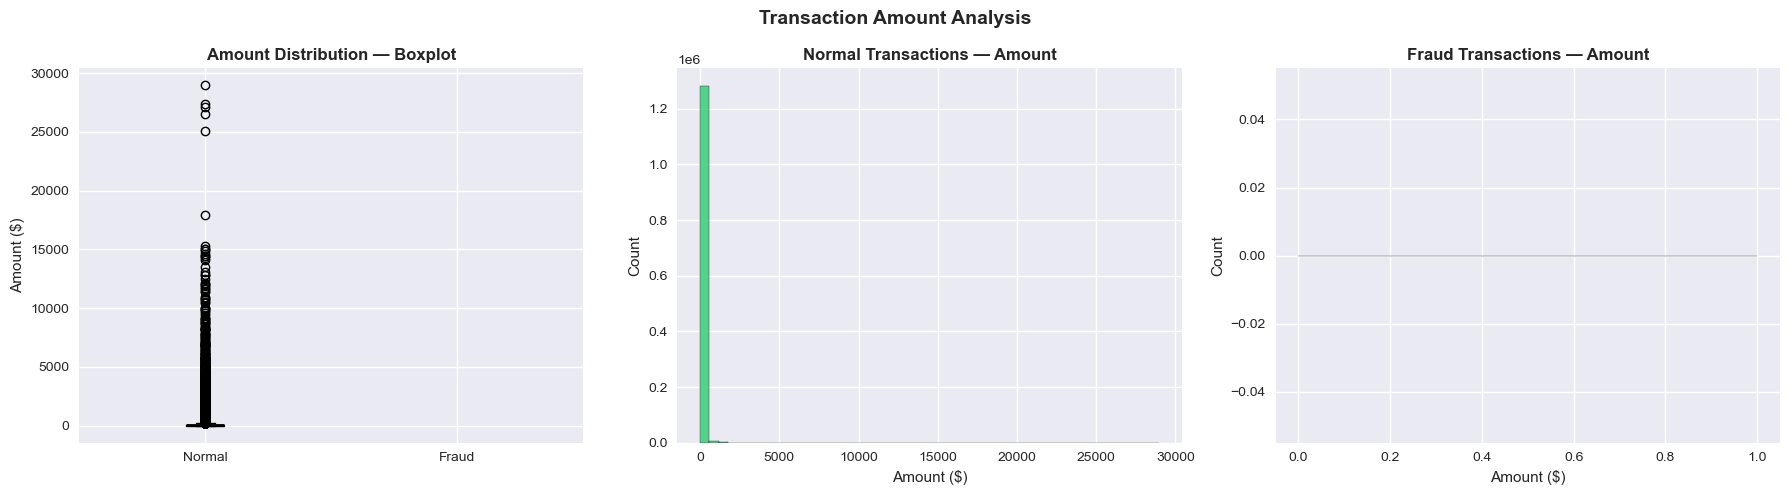

In [59]:
# ============================================================
# BLOCK 8 — Transaction Amount Analysis
# ============================================================

fraud_data  = train[train['is_fraud'] == 1]['amt']
normal_data = train[train['is_fraud'] == 0]['amt']

print("=" * 60)
print("TRANSACTION AMOUNT ANALYSIS")
print("=" * 60)
print(f"  Overall  — Min: ${train['amt'].min():.2f}"
      f"  Max: ${train['amt'].max():.2f}"
      f"  Mean: ${train['amt'].mean():.2f}")
print(f"  Fraud    — Mean: ${fraud_data.mean():.2f}"
      f"  Median: ${fraud_data.median():.2f}"
      f"  Max: ${fraud_data.max():.2f}")
print(f"  Normal   — Mean: ${normal_data.mean():.2f}"
      f"  Median: ${normal_data.median():.2f}"
      f"  Max: ${normal_data.max():.2f}")
print(f"\n  🔥 Fraud avg is"
      f"  {fraud_data.mean()/normal_data.mean():.1f}x"
      f"  higher than Normal avg!")
print("=" * 60)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Boxplot
axes[0].boxplot([normal_data, fraud_data],
                labels=['Normal', 'Fraud'],
                patch_artist=True,
                boxprops=dict(facecolor='#2ecc71'),
                medianprops=dict(color='black', linewidth=2))
axes[0].set_title('Amount Distribution — Boxplot',
                  fontweight='bold')
axes[0].set_ylabel('Amount ($)')

# Histogram — Normal
axes[1].hist(normal_data, bins=50,
             color='#2ecc71', edgecolor='black', alpha=0.8)
axes[1].set_title('Normal Transactions — Amount',
                  fontweight='bold')
axes[1].set_xlabel('Amount ($)')
axes[1].set_ylabel('Count')

# Histogram — Fraud
axes[2].hist(fraud_data, bins=50,
             color='#e74c3c', edgecolor='black', alpha=0.8)
axes[2].set_title('Fraud Transactions — Amount',
                  fontweight='bold')
axes[2].set_xlabel('Amount ($)')
axes[2].set_ylabel('Count')

plt.suptitle('Transaction Amount Analysis',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

FRAUD RATE BY CATEGORY
      category  Fraud_Count  Total  Fraud_Rate_%
  shopping_net         1713  97543          1.76
      misc_net          915  63287          1.45
   grocery_pos         1743 123638          1.41
  shopping_pos          843 116672          0.72
 gas_transport          618 131659          0.47
      misc_pos          250  79655          0.31
   grocery_net          134  45452          0.29
        travel          116  40507          0.29
 entertainment          233  94014          0.25
 personal_care          220  90758          0.24
     kids_pets          239 113035          0.21
   food_dining          151  91461          0.17
          home          198 123115          0.16
health_fitness          133  85879          0.15


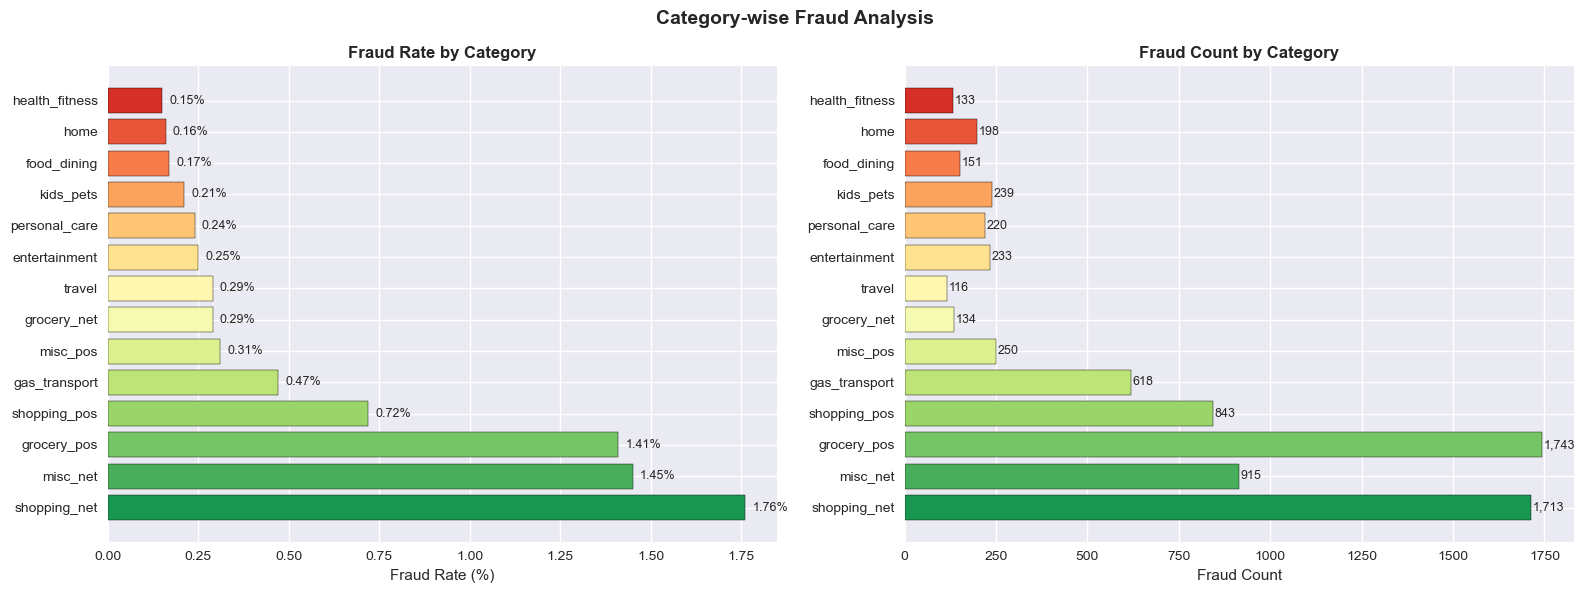

In [60]:
# ============================================================
# BLOCK 9 — Category-wise Fraud Analysis
# ============================================================

cat_stats = train.groupby('category')['is_fraud'].agg(
    Fraud_Count='sum',
    Total='count'
).reset_index()
cat_stats['Fraud_Rate_%'] = (cat_stats['Fraud_Count']
                              / cat_stats['Total'] * 100).round(2)
cat_stats = cat_stats.sort_values('Fraud_Rate_%', ascending=False)

print("=" * 60)
print("FRAUD RATE BY CATEGORY")
print("=" * 60)
print(cat_stats.to_string(index=False))
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Fraud rate bar
colors = plt.cm.RdYlGn_r(
    np.linspace(0.1, 0.9, len(cat_stats)))
axes[0].barh(cat_stats['category'],
             cat_stats['Fraud_Rate_%'],
             color=colors, edgecolor='black')
axes[0].set_xlabel('Fraud Rate (%)', fontsize=11)
axes[0].set_title('Fraud Rate by Category',
                  fontweight='bold', fontsize=12)
for i, v in enumerate(cat_stats['Fraud_Rate_%']):
    axes[0].text(v + 0.02, i, f'{v}%',
                 va='center', fontsize=9)

# Fraud count bar
axes[1].barh(cat_stats['category'],
             cat_stats['Fraud_Count'],
             color=colors, edgecolor='black')
axes[1].set_xlabel('Fraud Count', fontsize=11)
axes[1].set_title('Fraud Count by Category',
                  fontweight='bold', fontsize=12)
for i, v in enumerate(cat_stats['Fraud_Count']):
    axes[1].text(v + 5, i, f'{v:,}',
                 va='center', fontsize=9)

plt.suptitle('Category-wise Fraud Analysis',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

FRAUD ANALYSIS BY GENDER
gender  Fraud_Count  Total  Fraud_Rate_%
Female         3735 709863         0.526
  Male         3771 586812         0.643


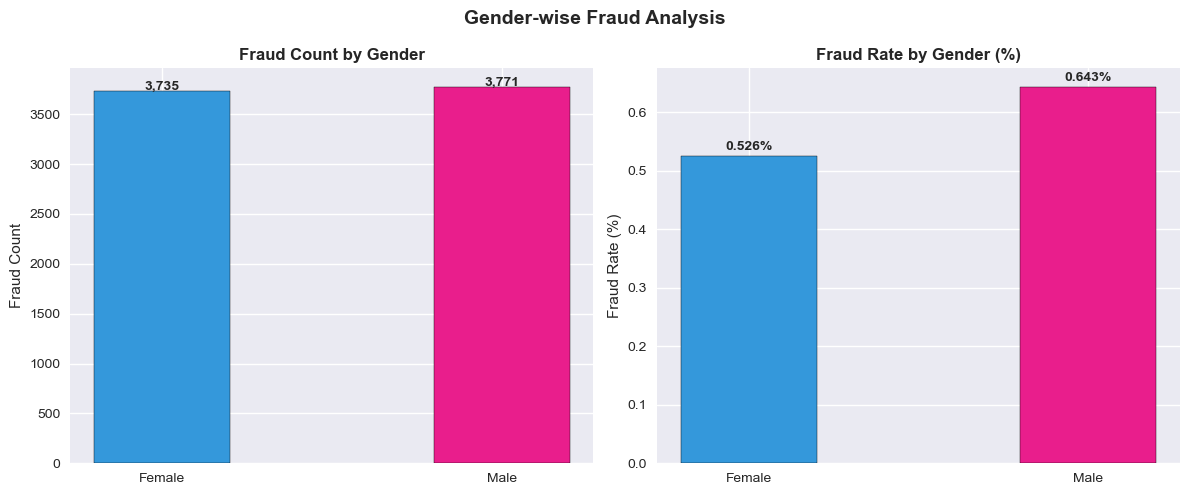

In [61]:
# ============================================================
# BLOCK 10 — Gender-wise Fraud Analysis
# ============================================================

gender_stats = train.groupby('gender')['is_fraud'].agg(
    Fraud_Count='sum',
    Total='count'
).reset_index()
gender_stats['Fraud_Rate_%'] = (gender_stats['Fraud_Count']
                                 / gender_stats['Total'] * 100).round(3)
gender_stats['gender'] = gender_stats['gender'].map(
    {'M': 'Male', 'F': 'Female'})

print("=" * 60)
print("FRAUD ANALYSIS BY GENDER")
print("=" * 60)
print(gender_stats.to_string(index=False))
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count
axes[0].bar(gender_stats['gender'],
            gender_stats['Fraud_Count'],
            color=['#3498db', '#e91e8c'],
            edgecolor='black', width=0.4)
axes[0].set_title('Fraud Count by Gender',
                  fontweight='bold')
axes[0].set_ylabel('Fraud Count')
for i, v in enumerate(gender_stats['Fraud_Count']):
    axes[0].text(i, v + 10, f'{v:,}',
                 ha='center', fontweight='bold')

# Rate
axes[1].bar(gender_stats['gender'],
            gender_stats['Fraud_Rate_%'],
            color=['#3498db', '#e91e8c'],
            edgecolor='black', width=0.4)
axes[1].set_title('Fraud Rate by Gender (%)',
                  fontweight='bold')
axes[1].set_ylabel('Fraud Rate (%)')
for i, v in enumerate(gender_stats['Fraud_Rate_%']):
    axes[1].text(i, v + 0.01, f'{v}%',
                 ha='center', fontweight='bold')

plt.suptitle('Gender-wise Fraud Analysis',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

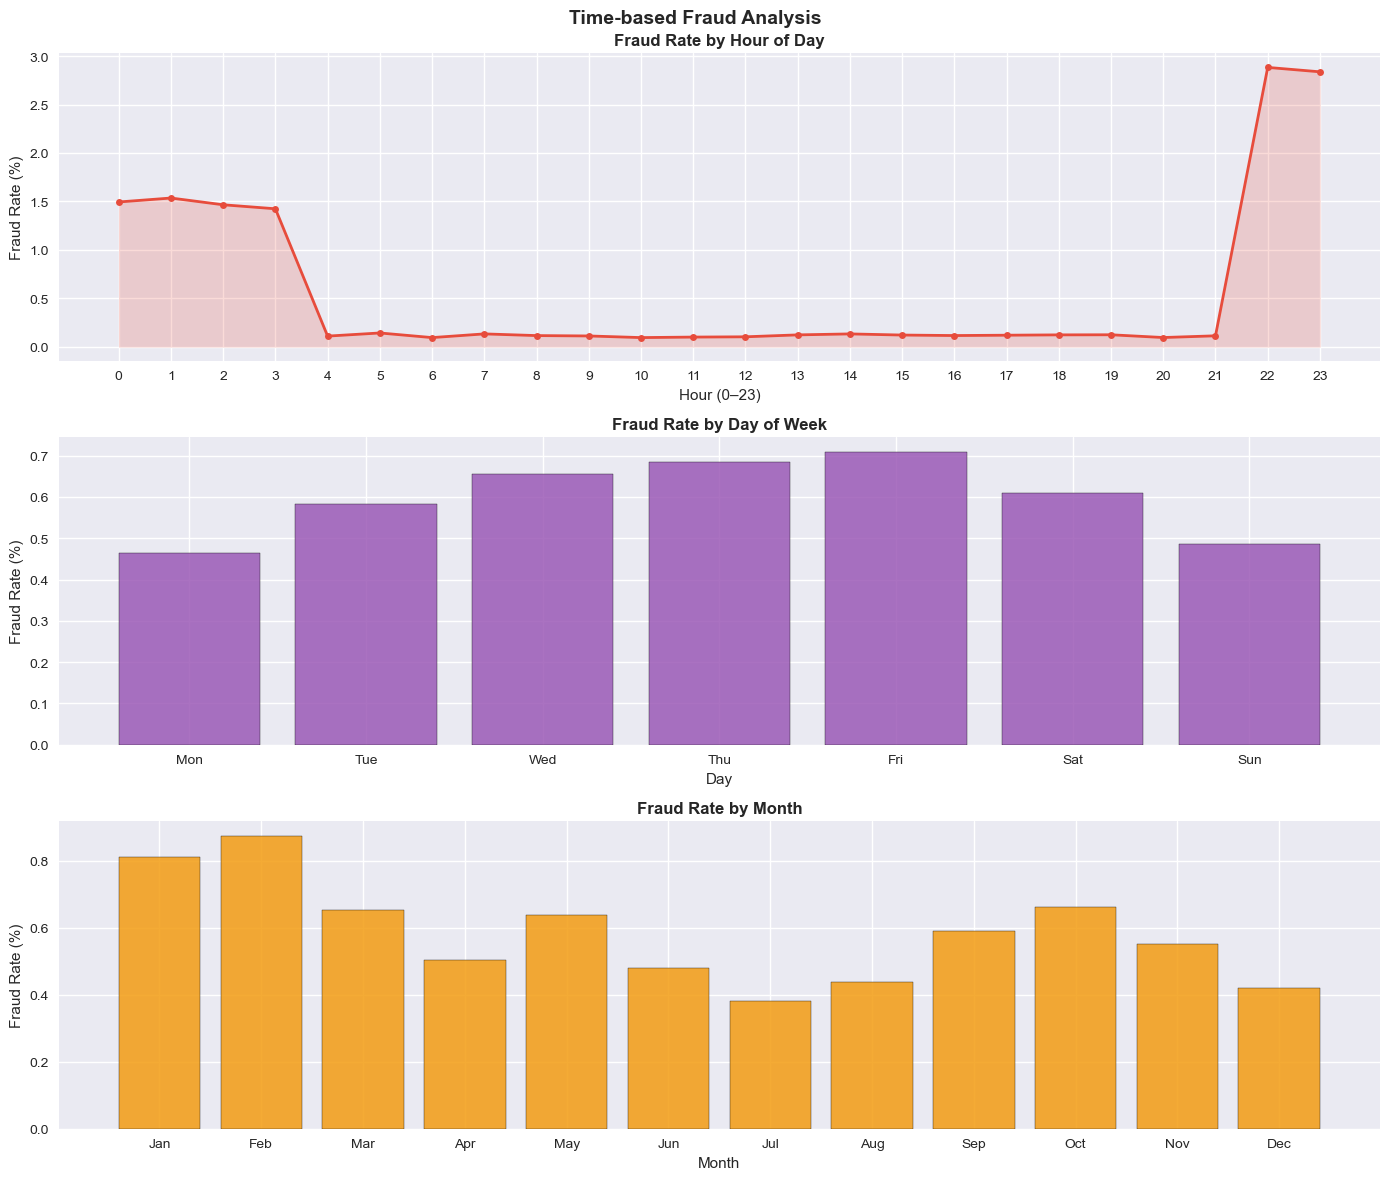


🔥 Peak fraud hour  : 22:00  (2.883%)
🔥 Peak fraud day   : Fri  (0.709%)
🔥 Peak fraud month : Feb  (0.873%)


In [62]:
# ============================================================
# BLOCK 11 — Time-based Fraud Analysis
# ============================================================

train['trans_date_trans_time'] = pd.to_datetime(
    train['trans_date_trans_time'])

train['hour']  = train['trans_date_trans_time'].dt.hour
train['day']   = train['trans_date_trans_time'].dt.dayofweek
train['month'] = train['trans_date_trans_time'].dt.month

hour_fraud  = train.groupby('hour')['is_fraud'].mean() * 100
day_fraud   = train.groupby('day')['is_fraud'].mean() * 100
month_fraud = train.groupby('month')['is_fraud'].mean() * 100

day_names   = ['Mon', 'Tue', 'Wed',
               'Thu', 'Fri', 'Sat', 'Sun']
month_names = ['Jan', 'Feb', 'Mar', 'Apr',
               'May', 'Jun', 'Jul', 'Aug',
               'Sep', 'Oct', 'Nov', 'Dec']

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Hourly
axes[0].plot(hour_fraud.index, hour_fraud.values,
             color='#e74c3c', lw=2, marker='o', markersize=5)
axes[0].fill_between(hour_fraud.index,
                     hour_fraud.values,
                     alpha=0.2, color='#e74c3c')
axes[0].set_title('Fraud Rate by Hour of Day',
                  fontweight='bold', fontsize=12)
axes[0].set_xlabel('Hour (0–23)')
axes[0].set_ylabel('Fraud Rate (%)')
axes[0].set_xticks(range(0, 24))

# Day of Week
axes[1].bar(range(7), day_fraud.values,
            color='#9b59b6', edgecolor='black', alpha=0.85)
axes[1].set_title('Fraud Rate by Day of Week',
                  fontweight='bold', fontsize=12)
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(day_names)

# Monthly
axes[2].bar(range(1, 13), month_fraud.values,
            color='#f39c12', edgecolor='black', alpha=0.85)
axes[2].set_title('Fraud Rate by Month',
                  fontweight='bold', fontsize=12)
axes[2].set_xlabel('Month')
axes[2].set_ylabel('Fraud Rate (%)')
axes[2].set_xticks(range(1, 13))
axes[2].set_xticklabels(month_names)

plt.suptitle('Time-based Fraud Analysis',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n🔥 Peak fraud hour  : {hour_fraud.idxmax()}:00"
      f"  ({hour_fraud.max():.3f}%)")
print(f"🔥 Peak fraud day   : {day_names[day_fraud.idxmax()]}"
      f"  ({day_fraud.max():.3f}%)")
print(f"🔥 Peak fraud month : {month_names[month_fraud.idxmax()-1]}"
      f"  ({month_fraud.max():.3f}%)")

TOP 15 STATES BY FRAUD RATE
state  Fraud_Count  Total  Fraud_Rate_%
   DE            9      9        100.00
   RI           15    550          2.73
   AK           36   2120          1.70
   NV           47   5607          0.84
   CO          113  13880          0.81
   TN          140  17554          0.80
   OR          149  18597          0.80
   NE          180  24168          0.74
   ME          119  16505          0.72
   NH           59   8278          0.71
   OH          321  46480          0.69
   VA          198  29250          0.68
   KS          156  22996          0.68
   FL          281  42671          0.66
   SC          193  29190          0.66


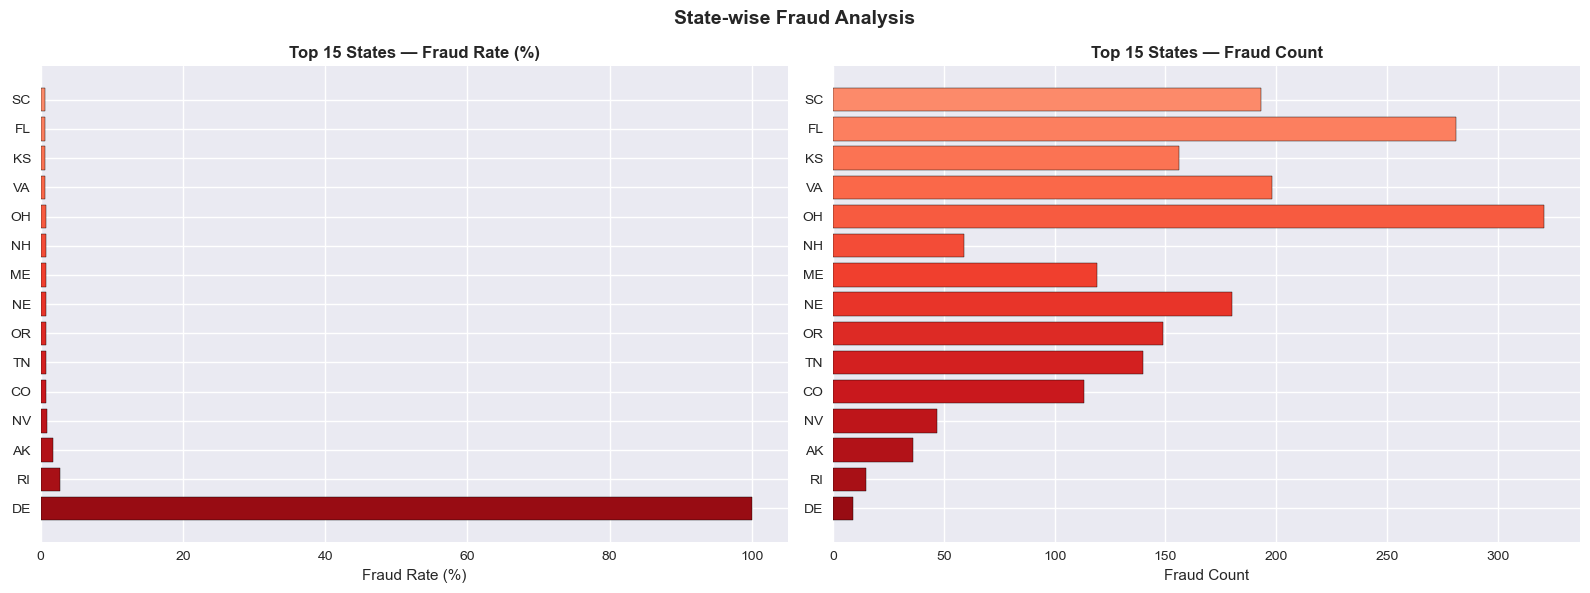

In [63]:
# ============================================================
# BLOCK 12 — Top States by Fraud
# ============================================================

state_stats = train.groupby('state')['is_fraud'].agg(
    Fraud_Count='sum',
    Total='count'
).reset_index()
state_stats['Fraud_Rate_%'] = (state_stats['Fraud_Count']
                                / state_stats['Total'] * 100).round(2)
top_states = state_stats.sort_values(
    'Fraud_Rate_%', ascending=False).head(15)

print("=" * 60)
print("TOP 15 STATES BY FRAUD RATE")
print("=" * 60)
print(top_states.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = plt.cm.Reds(
    np.linspace(0.4, 0.9, len(top_states)))[::-1]

axes[0].barh(top_states['state'],
             top_states['Fraud_Rate_%'],
             color=colors, edgecolor='black')
axes[0].set_title('Top 15 States — Fraud Rate (%)',
                  fontweight='bold')
axes[0].set_xlabel('Fraud Rate (%)')

axes[1].barh(top_states['state'],
             top_states['Fraud_Count'],
             color=colors, edgecolor='black')
axes[1].set_title('Top 15 States — Fraud Count',
                  fontweight='bold')
axes[1].set_xlabel('Fraud Count')

plt.suptitle('State-wise Fraud Analysis',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

TOP FEATURES CORRELATED WITH is_fraud
amt           0.219404
hour          0.013799
month         0.012409
unix_time     0.005078
zip           0.002162
city_pop      0.002136
lat           0.001894
merch_lat     0.001741
day           0.001739
merch_long    0.001721
long          0.001721
cc_num        0.000981


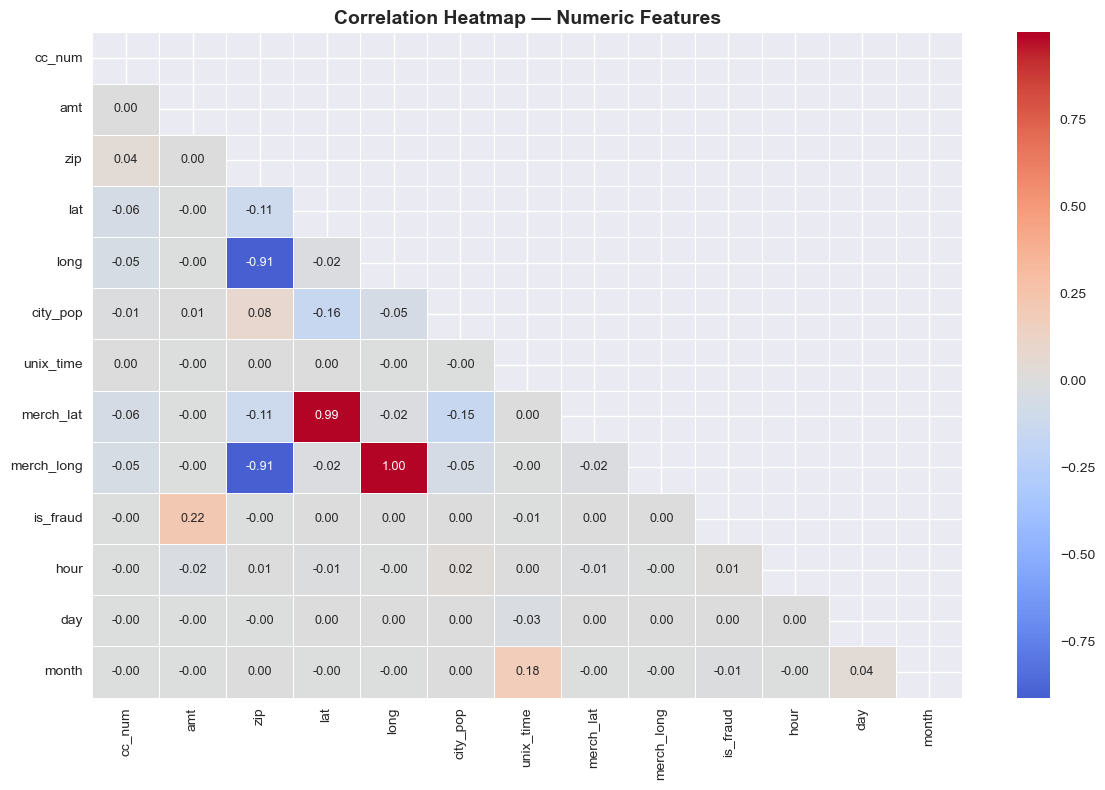

In [64]:
# ============================================================
# BLOCK 13 — Correlation Heatmap
# ============================================================

numeric_cols = train.select_dtypes(
    include=np.number).columns.tolist()

# Remove index col
if 'Unnamed: 0' in numeric_cols:
    numeric_cols.remove('Unnamed: 0')

corr_matrix = train[numeric_cols].corr()

print("=" * 60)
print("TOP FEATURES CORRELATED WITH is_fraud")
print("=" * 60)
fraud_corr = corr_matrix['is_fraud'].drop(
    'is_fraud').abs().sort_values(ascending=False)
print(fraud_corr.to_string())
print("=" * 60)

plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix,
            mask=mask,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            linewidths=0.5,
            annot_kws={'size': 9})
plt.title('Correlation Heatmap — Numeric Features',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

AGE ANALYSIS
  Overall  — Min: 21  Max: 101  Mean: 52.2
  Fraud    — Mean Age: 55.0
  Normal   — Mean Age: 52.2


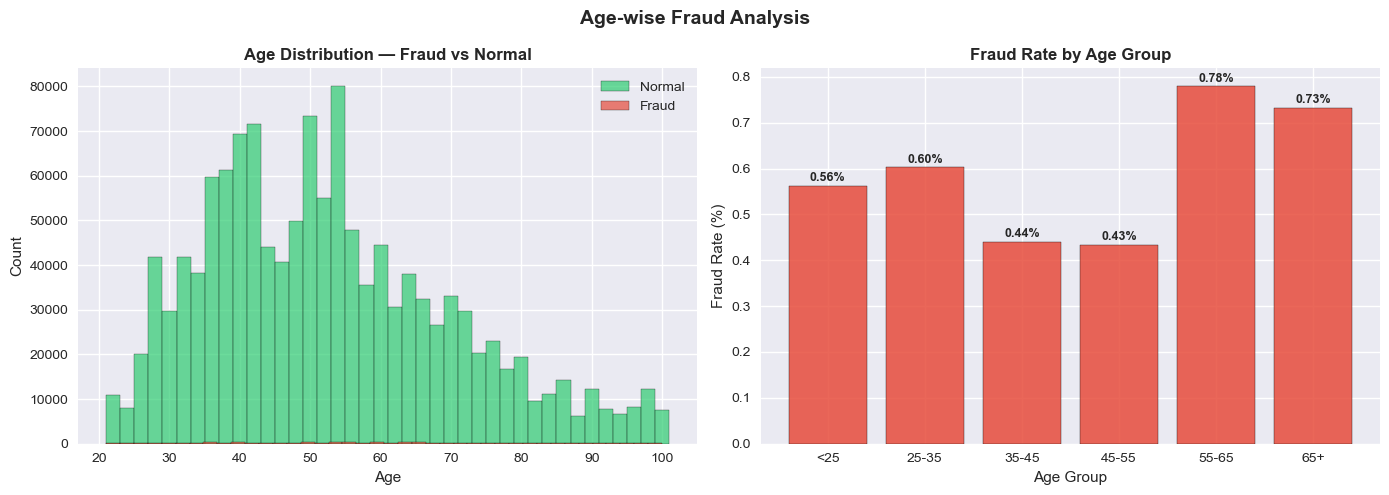

In [65]:
# ============================================================
# BLOCK 14 — Age Analysis
# ============================================================

train['dob'] = pd.to_datetime(train['dob'])
train['age'] = (pd.to_datetime('today') - train['dob']).dt.days // 365

fraud_age  = train[train['is_fraud'] == 1]['age']
normal_age = train[train['is_fraud'] == 0]['age']

print("=" * 60)
print("AGE ANALYSIS")
print("=" * 60)
print(f"  Overall  — Min: {train['age'].min()}"
      f"  Max: {train['age'].max()}"
      f"  Mean: {train['age'].mean():.1f}")
print(f"  Fraud    — Mean Age: {fraud_age.mean():.1f}")
print(f"  Normal   — Mean Age: {normal_age.mean():.1f}")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(normal_age, bins=40,
             alpha=0.7, color='#2ecc71',
             label='Normal', edgecolor='black')
axes[0].hist(fraud_age, bins=40,
             alpha=0.7, color='#e74c3c',
             label='Fraud', edgecolor='black')
axes[0].set_title('Age Distribution — Fraud vs Normal',
                  fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].legend()

# Age group fraud rate
train['age_group'] = pd.cut(
    train['age'],
    bins=[0, 25, 35, 45, 55, 65, 100],
    labels=['<25', '25-35', '35-45',
            '45-55', '55-65', '65+'])
age_fraud = train.groupby(
    'age_group', observed=True)['is_fraud'].mean() * 100

axes[1].bar(age_fraud.index.astype(str),
            age_fraud.values,
            color='#e74c3c', edgecolor='black', alpha=0.85)
axes[1].set_title('Fraud Rate by Age Group',
                  fontweight='bold')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Fraud Rate (%)')
for i, v in enumerate(age_fraud.values):
    axes[1].text(i, v + 0.01, f'{v:.2f}%',
                 ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Age-wise Fraud Analysis',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [66]:
# ============================================================
# BLOCK 15 — Final EDA Summary Report
# ============================================================

print("=" * 60)
print("       📋 EDA SUMMARY REPORT")
print("=" * 60)

print(f"""
📁 DATASET
   Train rows        : {len(train):,}
   Test  rows        : {len(test):,}
   Total columns     : 23
   Missing values    : None ✅
   Duplicate rows    : None ✅

🎯 FRAUD DISTRIBUTION
   Train fraud count : {train['is_fraud'].sum():,}
   Train fraud rate  : {train['is_fraud'].mean()*100:.4f}%
   Test  fraud count : {test['is_fraud'].sum():,}
   Test  fraud rate  : {test['is_fraud'].mean()*100:.4f}%
   Imbalance ratio   : {int((train['is_fraud']==0).sum() / train['is_fraud'].sum())} : 1

💰 AMOUNT INSIGHTS
   Fraud avg amount  : ${train[train['is_fraud']==1]['amt'].mean():.2f}
   Normal avg amount : ${train[train['is_fraud']==0]['amt'].mean():.2f}
   Fraud is          : {train[train['is_fraud']==1]['amt'].mean() / train[train['is_fraud']==0]['amt'].mean():.1f}x higher

🛍️  TOP FRAUD CATEGORY
   Highest fraud rate: {cat_stats.iloc[0]['category']}
   Fraud rate        : {cat_stats.iloc[0]['Fraud_Rate_%']}%

⏰ TIME INSIGHTS
   Peak fraud hour   : {hour_fraud.idxmax()}:00
   Peak fraud day    : {day_names[day_fraud.idxmax()]}
   Peak fraud month  : {month_names[month_fraud.idxmax()-1]}

🔑 KEY FEATURES FOR ML
   amt               : 🔥 Very High
   category          : 🔥 Very High
   hour              : ✅ High
   age               : ✅ High
   state             : ✅ Medium
   gender            : ⚠️  Low

⚠️  ACTIONS NEEDED
   → Apply SMOTE to fix class imbalance
   → Drop: Unnamed:0, cc_num, first, last, street, trans_num
   → Engineer: hour, day, month, age, distance
   → Encode: category, gender, state
""")
print("=" * 60)
print("✅ EDA COMPLETE — Ready for Preprocessing!")
print("   ➡️  Next: 02_preprocessing.ipynb")
print("=" * 60)

       📋 EDA SUMMARY REPORT

📁 DATASET
   Train rows        : 1,296,675
   Test  rows        : 555,719
   Total columns     : 23
   Missing values    : None ✅
   Duplicate rows    : None ✅

🎯 FRAUD DISTRIBUTION
   Train fraud count : 7,506
   Train fraud rate  : 0.5789%
   Test  fraud count : 2,145
   Test  fraud rate  : 0.3860%
   Imbalance ratio   : 171 : 1

💰 AMOUNT INSIGHTS
   Fraud avg amount  : $531.32
   Normal avg amount : $67.67
   Fraud is          : 7.9x higher

🛍️  TOP FRAUD CATEGORY
   Highest fraud rate: shopping_net
   Fraud rate        : 1.76%

⏰ TIME INSIGHTS
   Peak fraud hour   : 22:00
   Peak fraud day    : Fri
   Peak fraud month  : Feb

🔑 KEY FEATURES FOR ML
   amt               : 🔥 Very High
   category          : 🔥 Very High
   hour              : ✅ High
   age               : ✅ High
   state             : ✅ Medium
   gender            : ⚠️  Low

⚠️  ACTIONS NEEDED
   → Apply SMOTE to fix class imbalance
   → Drop: Unnamed:0, cc_num, first, last, street, trans_n